In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [92]:
df = pd.read_csv('/home/puru/Documents/House Price Prediction/STEP - 2 (Data Cleaning)/STEP - 2/1 - Outliers/gurgaon_properties_outlier_treated.csv')

In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,0.0,West,Moderately Old,NaN,NaN,2400.03,0,0,0,0,0,1,22
1,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,2.0,North-East,Relatively New,1650.00,NaN,1399.95,1,1,0,0,0,1,136
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,NaN,NaN,0,0,0,0,0,0,101
3,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,599.98,NaN,513.98,0,0,0,1,0,0,59
4,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.03,NaN,NaN,0,0,0,0,0,0,92


In [8]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1666
built_up_area          1966
carpet_area            1702
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

### Built up area

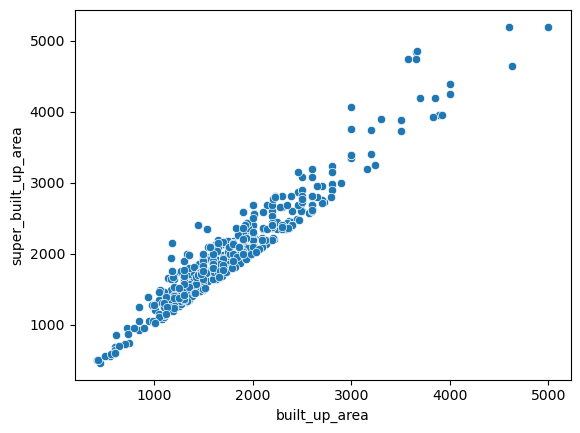

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])
plt.show()

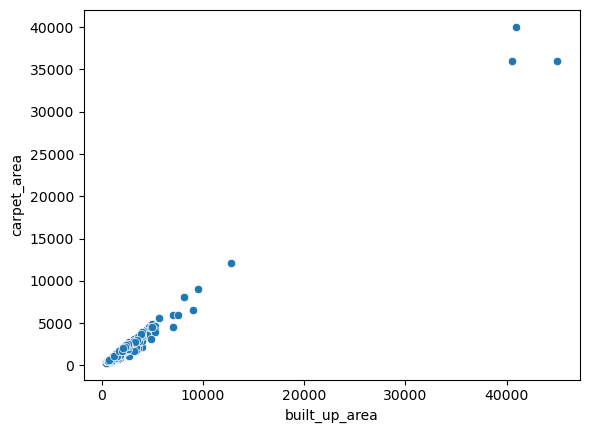

In [10]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])
plt.show()

In [11]:
df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


In [93]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [94]:
all_present_df.shape

(532, 23)

In [95]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [96]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [97]:
print(super_to_built_up_ratio)
print(carpet_to_built_up_ratio)

1.1063693961589496
0.9001774393686152


In [98]:
# super_built_up and carpet both present , but built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [99]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,2.0,North-East,Relatively New,1650.00,NaN,1399.95,1,1,0,0,0,1,136
3,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,599.98,NaN,513.98,0,0,0,1,0,0,59
7,flat,shree vardhman victoria,sector 70,1.10,8461.0,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet a...,2,2,2,0.0,West,New Property,1299.96,NaN,788.03,1,0,0,0,0,0,49
17,flat,aipl the peaceful homes,sector 70a,2.50,11627.0,2150.0,Super Built up area 2150(199.74 sq.m.)Carpet a...,3,3,3+,15.0,North-East,Relatively New,2149.98,NaN,1350.01,0,0,0,0,1,1,174
23,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.0,Super Built up area 1725(160.26 sq.m.)Carpet a...,3,3,3+,12.0,East,Relatively New,1725.02,NaN,1700.05,1,1,1,1,0,1,38


In [100]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

In [101]:
df.update(sbc_df)

In [102]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1666
built_up_area          1548
carpet_area            1702
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [103]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [104]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,NaN,NaN,0,0,0,0,0,0,101
4,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.03,NaN,NaN,0,0,0,0,0,0,92
8,flat,ansal heights 86,sector 86,0.87,5367.0,1621.0,Super Built up area 1360(126.35 sq.m.),2,2,1,12.0,North-East,New Property,1360.02,NaN,NaN,0,0,0,0,1,1,45
10,flat,ats tourmaline,sector 109,1.40,8000.0,1750.0,Super Built up area 1750(162.58 sq.m.),3,3,3+,9.0,East,Relatively New,1749.99,NaN,NaN,0,0,0,0,0,0,95
13,flat,antriksh heights,sector 84,0.60,5000.0,1200.0,Super Built up area 1200(111.48 sq.m.),2,2,2,14.0,North,Relatively New,1199.96,NaN,NaN,0,0,0,0,0,0,52


In [105]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

In [106]:
df.update(sb_df)

In [107]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1666
built_up_area           673
carpet_area            1702
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [108]:
# super_built_up and built_up are null, carpet is present
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [109]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,0.0,West,Moderately Old,NaN,NaN,2400.03,0,0,0,0,0,1,22
9,flat,gls avenue 51,sector 92,0.42,7106.0,591.0,Carpet area: 591 (54.91 sq.m.),2,2,1,4.0,East,Relatively New,NaN,NaN,591.05,1,0,0,1,0,1,42
16,flat,prime habitat,sector 99a,0.26,4745.0,548.0,Carpet area: 550 (51.1 sq.m.),2,2,1,6.0,North-East,Relatively New,NaN,NaN,550.04,0,0,0,0,1,0,79
21,flat,unitech uniworld gardens,sector 47,1.05,10531.0,997.0,Carpet area: 997 (92.62 sq.m.),2,2,2,3.0,North-East,Relatively New,NaN,NaN,996.95,0,0,0,0,0,1,34
24,flat,signature global grand iva,sector 103,0.30,8290.0,362.0,Carpet area: 361.88 (33.62 sq.m.),1,2,2,5.0,NaN,New Property,NaN,NaN,361.88,0,0,0,0,0,0,37


In [110]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

In [111]:
df.update(c_df)

In [112]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1666
built_up_area             0
carpet_area            1702
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

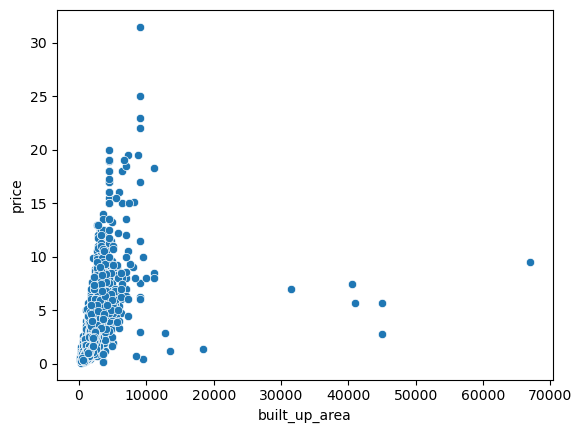

In [113]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])
plt.show()

In [143]:
anamoly_df = df[(df['built_up_area'] > 8000) & (df['price'] < 7)][['price','area','built_up_area']]

In [144]:
anamoly_df

,price,area,built_up_area
204,0.43,471.0,9449.95
550,6.25,9001.0,9000.02
694,0.72,7603.0,8448.00
2003,6.00,4140.0,9000.02
3000,2.95,1449.0,9000.02


In [145]:
anamoly_index = df[(df['built_up_area'] > 8000) & (df['price'] < 7)].index

In [146]:
df = df.drop(anamoly_index)

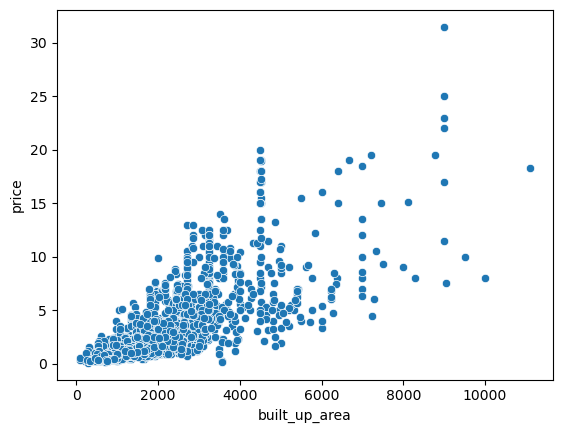

In [147]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])
plt.show()

In [148]:
anamoly_df = df[(df['price'] > 20)]

In [149]:
anamoly_df.shape

(4, 23)

In [150]:
anamoly_index = df[(df['price'] > 20)].index

In [151]:
df = df.drop(anamoly_index)

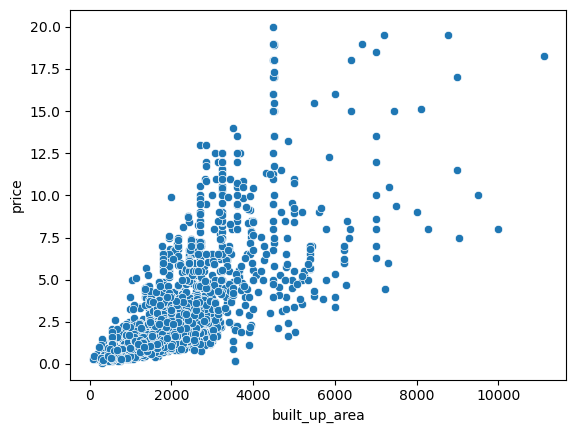

In [152]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])
plt.show()

### super built up area

In [154]:
super_to_carpet_ratio = (all_present_df['super_built_up_area']/all_present_df['carpet_area']).median()
super_to_carpet_ratio

1.2661495284562396

In [155]:
# both present , but built up null
df1 = df[(df['super_built_up_area'].isnull()) & ~(df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [156]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,0.0,West,Moderately Old,2992.86,2667.0,2400.03,0,0,0,0,0,1,22
1,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,2.0,North-East,Relatively New,1650.00,1524.0,1399.95,1,1,0,0,0,1,136
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,1539.0,NaN,0,0,0,0,0,0,101
3,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,599.98,557.0,513.98,0,0,0,1,0,0,59
4,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.03,1611.0,NaN,0,0,0,0,0,0,92


In [157]:
df1['super_built_up_area'].fillna(round(((df1['built_up_area']*1.105) + df1['carpet_area']*1.2661)/2 ,2),inplace=True)

In [158]:
df.update(df1)

In [159]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1000
agePossession             0
super_built_up_area       0
built_up_area             0
carpet_area            1689
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [160]:
# sb present c is null built up null
df2 = df[(df['super_built_up_area'].isnull()) & ~(df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [161]:
df2.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


In [162]:
df2['super_built_up_area'].fillna(round(((df2['built_up_area']*1.106))),inplace=True)

In [163]:
df.update(df2)

In [164]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1000
agePossession             0
super_built_up_area       0
built_up_area             0
carpet_area            1689
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

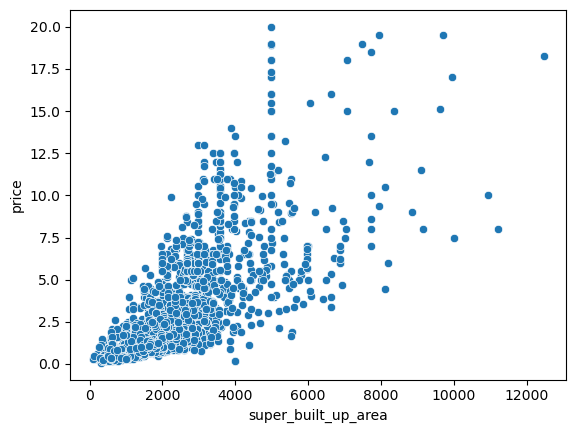

In [165]:
sns.scatterplot(x=df['super_built_up_area'],y=df['price'])
plt.show()

### carpet area

In [166]:
df3 = df[~(df['super_built_up_area'].isnull()) & ~(df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [167]:
df3.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,1539.00,NaN,0,0,0,0,0,0,101
4,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.03,1611.00,NaN,0,0,0,0,0,0,92
6,house,independent,sector 17,0.32,22068.0,145.0,Built Up area: 145 (13.47 sq.m.),2,2,0,3.0,NaN,Undefined,160.00,144.99,NaN,0,0,0,0,0,0,0
8,flat,ansal heights 86,sector 86,0.87,5367.0,1621.0,Super Built up area 1360(126.35 sq.m.),2,2,1,12.0,North-East,New Property,1360.02,1231.00,NaN,0,0,0,0,1,1,45
10,flat,ats tourmaline,sector 109,1.40,8000.0,1750.0,Super Built up area 1750(162.58 sq.m.),3,3,3+,9.0,East,Relatively New,1749.99,1584.00,NaN,0,0,0,0,0,0,95


In [168]:
df3['carpet_area'].fillna(round (  ( df3['built_up_area']*0.9 )  ) ,inplace=True)

In [169]:
df.update(df3)

In [170]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1000
agePossession             0
super_built_up_area       0
built_up_area             0
carpet_area               0
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

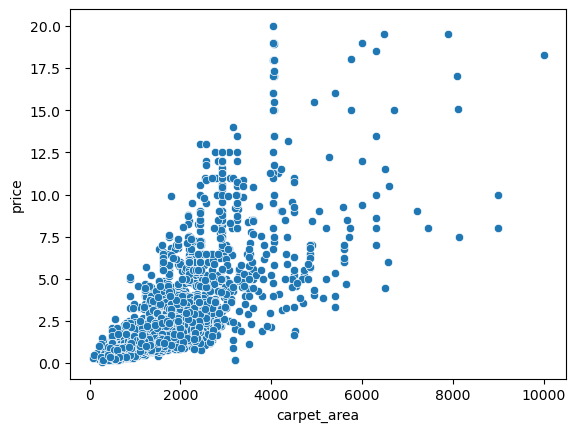

In [171]:
sns.scatterplot(x=df['carpet_area'],y=df['price'])
plt.show()

### floorNum

In [172]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
27,house,independent,sector 3,1.50,10288.0,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,0,NaN,NaN,Old Property,2088.00,1890.03,1701.00,0,0,0,0,0,0,0
40,house,vipul tatvam villa,sector 48,8.50,26235.0,3240.0,Plot area 360(301.01 sq.m.),4,4,1,NaN,NaN,Relatively New,3580.00,3240.04,2916.00,0,0,0,0,0,0,21
90,flat,NaN,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,NaN,NaN,Under Construction,1796.00,1625.03,1463.00,0,0,0,0,0,0,0
737,house,ansal sushant lok plots,sector 43,3.30,26570.0,1242.0,Plot area 138(115.39 sq.m.),1,1,0,NaN,NaN,Under Construction,1372.00,1242.05,1118.00,0,0,0,0,0,0,0
1161,house,dlf new town heights,sector 86,2.47,7718.0,3200.0,Plot area 3200(297.29 sq.m.)Built Up area: 280...,4,4,3+,NaN,West,Moderately Old,2939.73,2800.01,2200.03,0,1,0,1,0,1,130
1287,house,vipul tatvam villa,sector 48,8.50,26235.0,3240.0,Plot area 360(301.01 sq.m.),4,4,2,NaN,East,Moderately Old,3580.00,3240.04,2916.00,0,1,1,1,0,0,88
1304,house,independent,sector 4,0.65,11111.0,585.0,Plot area 65(54.35 sq.m.),4,2,2,NaN,NaN,Moderately Old,646.00,585.02,527.00,0,0,0,0,0,0,0
1568,house,independent,sector 24,1.45,26852.0,540.0,Plot area 60(50.17 sq.m.),3,3,1,NaN,NaN,Old Property,597.00,540.02,486.00,0,0,0,0,0,0,9
1579,flat,experion heartsong,dwarka expressway,1.08,6150.0,1756.0,Built Up area: 1758 (163.32 sq.m.),3,3,0,NaN,NaN,Under Construction,1943.00,1757.96,1582.00,0,0,0,0,0,0,0
1714,house,jacob pura,sector 12,0.35,9722.0,360.0,Built Up area: 360 (33.45 sq.m.),2,1,0,NaN,NaN,Old Property,398.00,360.05,324.00,0,0,0,0,0,0,0


In [173]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [174]:
df['floorNum'].fillna(2.0,inplace=True)

In [175]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                  0
facing                 1000
agePossession             0
super_built_up_area       0
built_up_area             0
carpet_area               0
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [176]:
1011/df.shape[0]

0.287624466571835

### facing

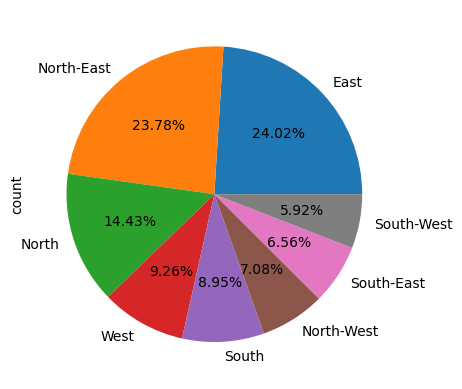

In [177]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')
plt.show()

In [178]:
df.drop(columns=['facing'],inplace=True)

In [179]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3068,house,vipul tatvam villa,sector 48,18.50,26428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,1,1.0,Moderately Old,7735.00,6999.98,6300.00,0,0,0,0,0,0,30
3146,flat,the lions cghs,sector 56,2.10,8750.0,2400.0,Super Built up area 2400(222.97 sq.m.)Built Up...,3,4,3+,8.0,Old Property,2400.03,2200.03,2000.04,0,0,0,0,1,1,166
806,flat,imperia the esfera,sector 37c,0.86,4886.0,1760.0,Super Built up area 1760(163.51 sq.m.),3,3,2,0.0,New Property,1760.01,1593.00,1434.00,0,0,0,0,1,0,35
1891,flat,puri emerald bay,sector 104,2.25,10465.0,2150.0,Super Built up area 2450(227.61 sq.m.)Carpet a...,3,4,3+,4.0,Relatively New,2449.97,2303.00,2149.98,0,1,0,0,0,1,159
2731,flat,pareena mi casa,sector 68,1.10,9020.0,1220.0,Super Built up area 1245(115.66 sq.m.)Carpet a...,2,2,3,13.0,New Property,1244.95,1244.00,1225.04,0,0,0,0,0,0,106


In [180]:
df.isnull().sum()

property_type          0
society                1
sector                 0
price                  0
price_per_sqft         0
area                   0
areaWithType           0
bedRoom                0
bathroom               0
balcony                0
floorNum               0
agePossession          0
super_built_up_area    0
built_up_area          0
carpet_area            0
study room             0
servant room           0
store room             0
pooja room             0
others                 0
furnishing_type        0
luxury_score           0
dtype: int64

In [181]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
90,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,2.0,Under Construction,1796.0,1625.03,1463.0,0,0,0,0,0,0,0


In [182]:
df.drop(index=[90],inplace=True)

In [183]:
df.isnull().sum()

property_type          0
society                0
sector                 0
price                  0
price_per_sqft         0
area                   0
areaWithType           0
bedRoom                0
bathroom               0
balcony                0
floorNum               0
agePossession          0
super_built_up_area    0
built_up_area          0
carpet_area            0
study room             0
servant room           0
store room             0
pooja room             0
others                 0
furnishing_type        0
luxury_score           0
dtype: int64

### agePossession

In [184]:
df['agePossession'].value_counts()

agePossession
Relatively New        1594
New Property           557
Moderately Old         531
Undefined              289
Old Property           282
Under Construction     261
Name: count, dtype: int64

In [185]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
6,house,independent,sector 17,0.32,22068.0,145.0,Built Up area: 145 (13.47 sq.m.),2,2,0,3.0,Undefined,160.00,144.99,130.00,0,0,0,0,0,0,0
12,flat,sapphire eighty three,sector 83,0.65,9286.0,700.0,Built Up area: 700 (65.03 sq.m.),1,1,0,6.0,Undefined,773.00,699.98,630.00,0,0,0,0,0,0,0
29,flat,godrej,sector 79,2.50,11141.0,2244.0,Built Up area: 2244 (208.47 sq.m.)Carpet area:...,3,3,3+,5.0,Undefined,2379.30,2243.95,1800.05,0,0,0,0,0,0,0
35,house,independent,sector 56,2.95,20233.0,1458.0,Built Up area: 162 (135.45 sq.m.),2,2,0,1.0,Undefined,1611.00,1457.97,1312.00,0,0,0,0,0,0,0
39,house,independent,sector 37d,1.16,7539.0,1539.0,Built Up area: 1535 (142.61 sq.m.),1,1,0,1.0,Undefined,1696.00,1535.04,1382.00,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382,flat,umang winter hills,sector 77,1.20,6586.0,1822.0,Built Up area: 1822 (169.27 sq.m.)Carpet area:...,3,3,3,14.0,Undefined,1766.30,1822.01,1199.96,0,0,0,0,0,0,46
3489,house,independent,sector 3,0.90,8928.0,1008.0,Built Up area: 1008 (93.65 sq.m.),3,1,0,1.0,Undefined,1114.00,1008.04,907.00,0,0,0,0,0,0,0
3497,flat,conscient one,sector 109,1.70,17617.0,965.0,Built Up area: 965 (89.65 sq.m.)Carpet area: 6...,1,1,2,9.0,Undefined,930.69,964.98,627.97,0,0,0,0,0,0,0
3525,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,1000.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,0,1.0,Undefined,999.97,758.00,550.04,0,0,0,0,0,0,0


In [186]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [187]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [188]:
df['agePossession'].value_counts()

agePossession
Relatively New        1701
New Property           598
Moderately Old         572
Old Property           308
Under Construction     275
Undefined               60
Name: count, dtype: int64

In [189]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [190]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [191]:
df['agePossession'].value_counts()

agePossession
Relatively New        1716
New Property           599
Moderately Old         579
Old Property           318
Under Construction     275
Undefined               27
Name: count, dtype: int64

In [192]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [193]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [194]:
df['agePossession'].value_counts()

agePossession
Relatively New        1718
Moderately Old         604
New Property           599
Old Property           318
Under Construction     275
Name: count, dtype: int64

In [195]:
df.isnull().sum()

property_type          0
society                0
sector                 0
price                  0
price_per_sqft         0
area                   0
areaWithType           0
bedRoom                0
bathroom               0
balcony                0
floorNum               0
agePossession          0
super_built_up_area    0
built_up_area          0
carpet_area            0
study room             0
servant room           0
store room             0
pooja room             0
others                 0
furnishing_type        0
luxury_score           0
dtype: int64

In [196]:
df.drop(columns=['area','areaWithType'],inplace=True)

In [197]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [198]:
df.shape

(3514, 20)